# Deploy Yolo in MLFlow

In [1]:
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import io
import base64
import mlflow
import numpy as np
import random
from copy import deepcopy

### Берем изображение

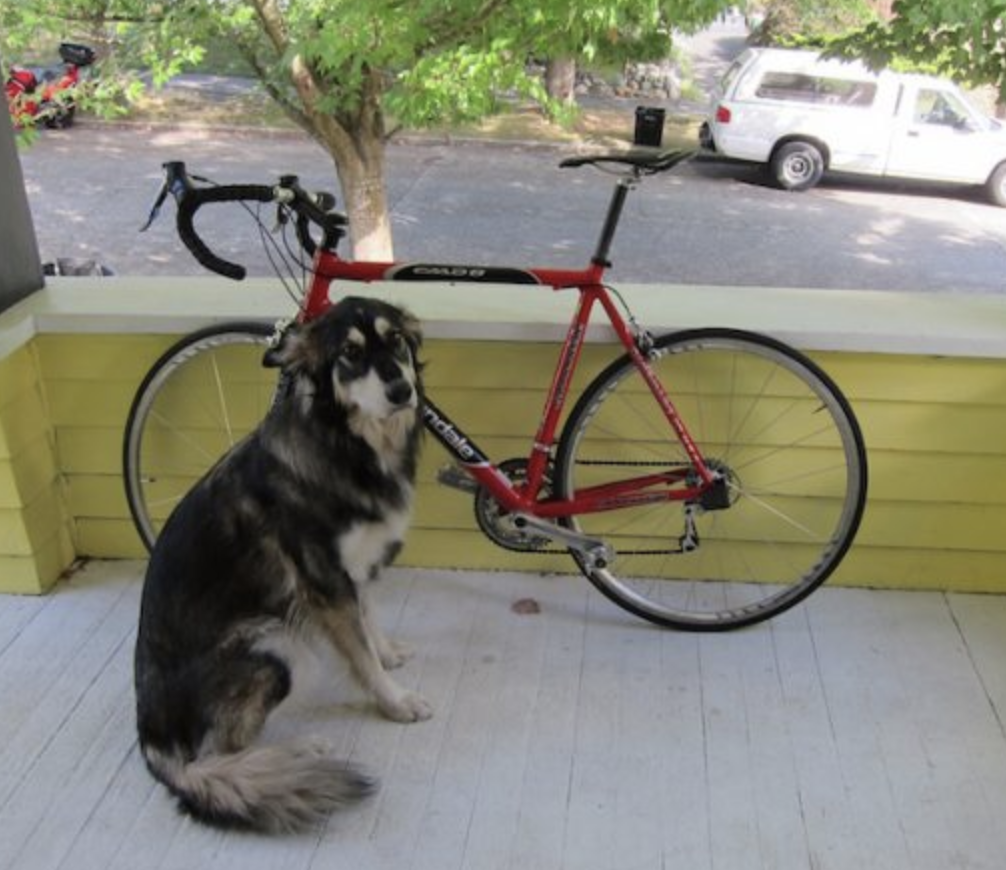

In [2]:
response = requests.get(
    "https://lh7-us.googleusercontent.com/GNVsVvVmCDLtFtqburTWaTQOjXn3N0wLBKXt6BhXO2GG037S9o7xZ7HyPjFcJoWgds1PFKvbHgCCEWTqiB-MR0VFIo7UC7jVEX6t10LD6zPg61YoEAR-NGbA2RJj7dVdYwMH2nsOJY648uXmMlpNiZw"
)
img = Image.open(BytesIO(response.content)).convert("RGB")
img

### Пробуем запустить модель в ноутбуке

In [3]:
model = YOLO("./custom_model/artifacts/yolo11n.pt")
model = model.to(device="mps")


0: 576x640 1 bicycle, 1 car, 1 truck, 1 dog, 475.6ms
Speed: 10.0ms preprocess, 475.6ms inference, 129.7ms postprocess per image at shape (1, 3, 576, 640)


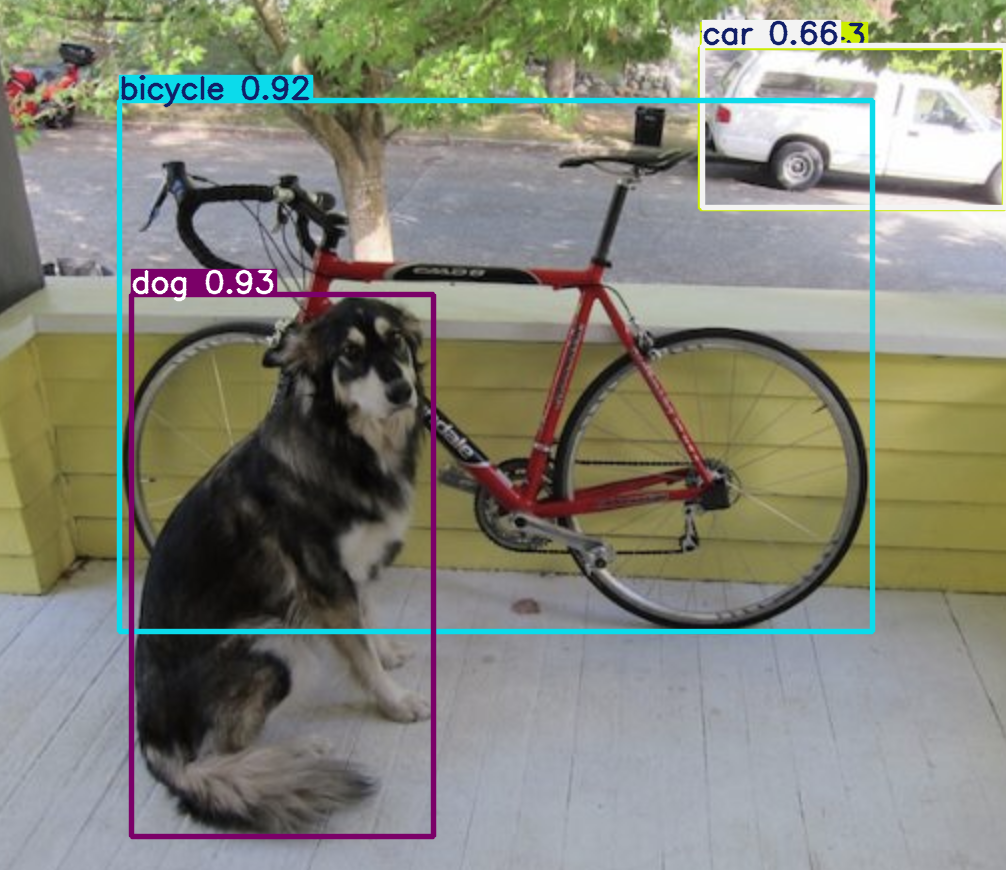

In [4]:
result = Image.fromarray(model.predict(img)[0].plot())
b, g, r = result.split()
result = Image.merge("RGB", (r, g, b))
result

### Создаем файл с классом оберткой

In [ ]:
%%file yolo_model_mlflow_wrapper.py
import base64
import io
from typing import Any, Dict

import cv2
import mlflow.pyfunc
import numpy as np
from PIL import Image
from ultralytics import YOLO


def base64_to_ndarray(base64_str):
    img_data = base64.b64decode(base64_str)
    pil_image = Image.open(io.BytesIO(img_data))
    return np.array(pil_image.convert("RGB"), dtype=np.uint8)


class MLFlowYOLO(mlflow.pyfunc.PythonModel):
    def __init__(self):
        pass

    def load_context(self, context):
        print("load_context")
        self.my_model = YOLO(context.artifacts["model"])
        print("load_context")

    def predict(self, context, model_input, params):
        print("predict")
        if isinstance(model_input, str):
            img = base64_to_ndarray(model_input)
        elif isinstance(model_input, np.ndarray):
            print(model_input.dtype)
            if model_input.dtype == "str":
                img = base64_to_ndarray(model_input)
            else:
                img = np.array(model_input, dtype=np.uint8)
        else:
            raise ValueError("Input must be image path or numpy array")

        pred = self.my_model.predict(img)[0]
        predictions = []

        for cord, c, conf in zip(pred.boxes.xyxy, pred.boxes.cls, pred.boxes.conf):
            predictions.append(
                {
                    "bbox": [int(x) for x in cord],
                    "confidence": float(conf),
                    "class": int(c),
                    "class_name": pred.names[int(c)],
                }
            )

        return predictions

Overwriting yolo_model_mlflow_wrapper.py


### Создаем артифакт 

In [6]:
from yolo_model_mlflow_wrapper import MLFlowYOLO

mlflow.set_tracking_uri(uri="http://127.0.0.1:8098")
custom_model = MLFlowYOLO()

with mlflow.start_run():
    info = mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=custom_model,
        conda_env={
            "name": "yolo_env",
            "dependencies": [
                "python=3.10",
                {
                    "pip": [
                        "ultralytics",
                        "torch",
                        "mlflow",
                        "matplotlib-inline",
                        "opencv-python",
                        "numpy",
                        "pillow",
                    ]
                },
            ],
        },
        artifacts={"model": "./custom_model/artifacts/yolo11n.pt"},
        code_paths=["yolo_model_mlflow_wrapper.py"],
    )
model_uri = info._model_uri
model_uri

/Users/pavel/miniconda3/envs/mlflow_yolo/lib/python3.10/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/Users/pavel/miniconda3/envs/mlflow_yolo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load_context
load_context


2025/05/02 15:23:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run whimsical-finch-917 at: http://127.0.0.1:8098/#/experiments/0/runs/7239d571ee654defa9f1096bb4070ea8
🧪 View experiment at: http://127.0.0.1:8098/#/experiments/0


'runs:/7239d571ee654defa9f1096bb4070ea8/model'

### Пробуем вызвать артифакт с моделью пока не создавая образ

In [7]:
mlflow.models.predict(
    model_uri=model_uri,
    input_data=np.array(img.convert("RGB")),
    env_manager="conda",
)

2025/05/02 15:23:59 INFO mlflow.models.python_api: It is highly recommended to use `uv` as the environment manager for predicting with MLflow models as its performance is significantly better than other environment managers. Run `pip install uv` to install uv. See https://docs.astral.sh/uv/getting-started/installation for other installation methods.
2025/05/02 15:24:01 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'
2025/05/02 15:24:02 INFO mlflow.utils.conda: === Creating conda environment /var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmp0q3ypvja/envs/conda_envs/mlflow-294686f38abe6b682d53ee251bd8ca56cc2d533f-a3606fdb15d45bfc50ebb4e1d2da9dd8c1a9ffc4 ===


Channels:
 - defaults
Platform: osx-arm64
Solving environment: ...working... done

Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Installing pip dependencies: ...working... 

2025/05/02 15:33:52 INFO mlflow.utils.environment: === Running command '['bash', '-c', 'source /Users/pavel/miniconda3/bin/../etc/profile.d/conda.sh && conda activate mlflow-294686f38abe6b682d53ee251bd8ca56cc2d533f-a3606fdb15d45bfc50ebb4e1d2da9dd8c1a9ffc4 1>&2 && python -c ""']'


Ran pip subprocess with arguments:
['/var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmp0q3ypvja/envs/conda_envs/mlflow-294686f38abe6b682d53ee251bd8ca56cc2d533f-a3606fdb15d45bfc50ebb4e1d2da9dd8c1a9ffc4/bin/python', '-m', 'pip', 'install', '-U', '-r', '/var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmpxcf81onp/model/condaenv.p20falzc.requirements.txt', '--exists-action=b']
Pip subprocess output:
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 458.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 738.6 kB/s eta 0:00:0000:01m0:030m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 479.3 kB/s eta 0:00:0000:0100:03mm
   ━━━━━━━━━���━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 525.3 kB/s eta 0:00:000:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 484.8 kB/s eta 0:00:00a 0:00:01mm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.2/700.2 kB 328.2 kB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 387

2025/05/02 15:33:52 INFO mlflow.utils.environment: === Running command '['bash', '-c', 'source /Users/pavel/miniconda3/bin/../etc/profile.d/conda.sh && conda activate mlflow-294686f38abe6b682d53ee251bd8ca56cc2d533f-a3606fdb15d45bfc50ebb4e1d2da9dd8c1a9ffc4 1>&2 && python /Users/pavel/miniconda3/envs/mlflow_yolo/lib/python3.10/site-packages/mlflow/pyfunc/_mlflow_pyfunc_backend_predict.py --model-uri file:///var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmpxcf81onp/model --content-type json --input-path /var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmp7sn5um9c/input.json']'
/var/folders/bm/6sf1ct396kg9hjg882z2h7_r0000gn/T/tmp0q3ypvja/envs/conda_envs/mlflow-294686f38abe6b682d53ee251bd8ca56cc2d533f-a3606fdb15d45bfc50ebb4e1d2da9dd8c1a9ffc4/lib/python3.10/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/p

load_context
load_context
predict
int64
<class 'numpy.ndarray'>

0: 576x640 1 bicycle, 1 car, 1 dog, 59.9ms
Speed: 5.0ms preprocess, 59.9ms inference, 4.2ms postprocess per image at shape (1, 3, 576, 640)
{"predictions": [{"bbox": [117, 91, 871, 629], "confidence": 0.9414252042770386, "class": 1, "class_name": "bicycle"}, {"bbox": [131, 294, 433, 837], "confidence": 0.9358384609222412, "class": 16, "class_name": "dog"}, {"bbox": [705, 44, 1005, 208], "confidence": 0.704939603805542, "class": 2, "class_name": "car"}]}

### Ответ приходит, попробуем полноценно поднять модель локально

```bash
mlflow models serve -m  runs:/{run_id}/model --env-manager conda
```

In [8]:
def pil_to_base64(pil_image, format="png"):
    buffered = io.BytesIO()
    pil_image.save(buffered, format=format)
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


def plot_bboxes_pil(image, detections, font_scale=1, thickness=2):
    image = deepcopy(image)
    draw = ImageDraw.Draw(image)
    try:
        font = ImageFont.truetype("arial.ttf", size=int(15 * font_scale))
    except:
        font = ImageFont.load_default()

    class_colors = {}

    for detection in detections:
        x1, y1, x2, y2 = detection["bbox"]
        class_id = detection["class"]
        class_name = detection["class_name"]
        confidence = detection["confidence"]

        if class_id not in class_colors:
            class_colors[class_id] = (
                random.randint(0, 255),
                random.randint(0, 255),
                random.randint(0, 255),
            )
        color = class_colors[class_id]
        draw.rectangle([x1, y1, x2, y2], outline=color, width=thickness)
        label = f"{class_name} {confidence:.2f}"
        text_bbox = draw.textbbox((0, 0), label, font=font)
        text_width = text_bbox[2] - text_bbox[0]
        text_height = text_bbox[3] - text_bbox[1]
        draw.rectangle([x1, y1 - text_height - 5, x1 + text_width, y1], fill=color)

        draw.text((x1, y1 - text_height - 2), label, fill=(0, 0, 0), font=font)

    return image

In [9]:
headers = {
    "Content-Type": "application/json",
}

img_64 = pil_to_base64(img)

data = {"inputs": img_64}

response = requests.post(
    "http://127.0.0.1:5000/invocations", headers=headers, json=data
)
print(response.status_code)
if response.status_code == 200:
    print(response.json())
    pred = response.json()["predictions"]

200
{'predictions': [{'bbox': [117, 91, 871, 629], 'confidence': 0.9414252042770386, 'class': 1, 'class_name': 'bicycle'}, {'bbox': [131, 294, 433, 837], 'confidence': 0.9358384609222412, 'class': 16, 'class_name': 'dog'}, {'bbox': [705, 44, 1005, 208], 'confidence': 0.704939603805542, 'class': 2, 'class_name': 'car'}]}


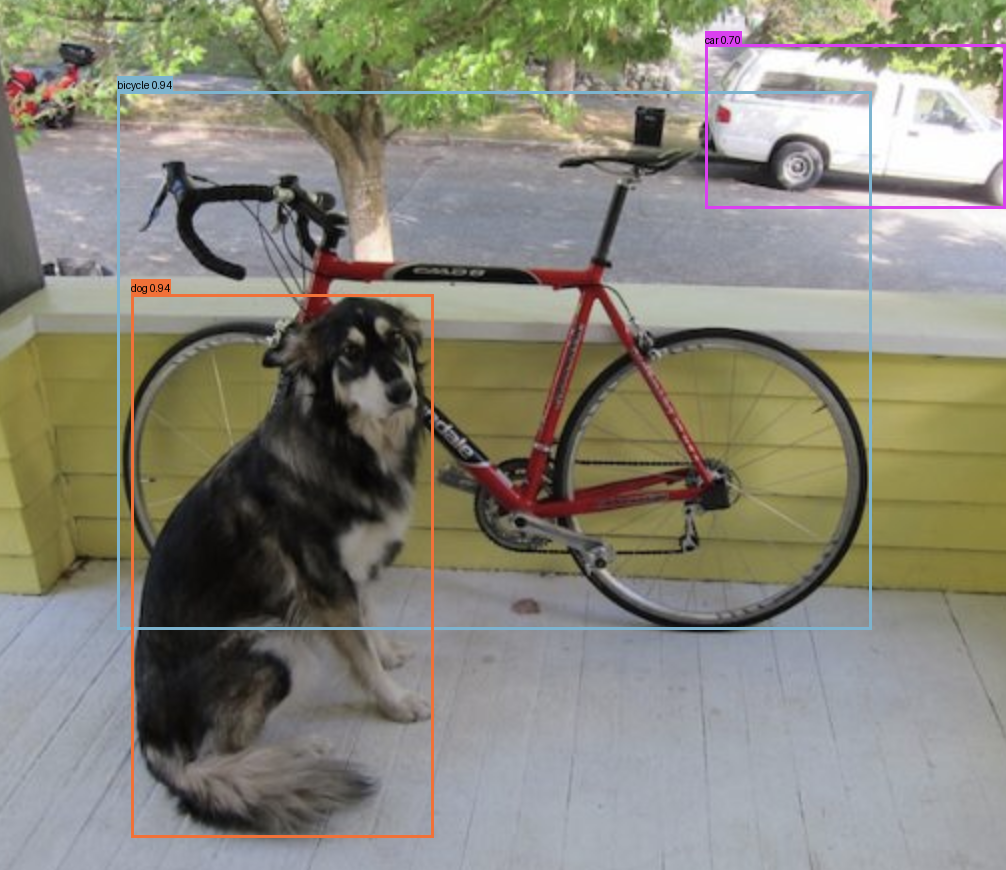

In [10]:
plot_bboxes_pil(img, pred, font_scale=2, thickness=3)

### Работает, упаковываем в Docker Image

```bash
mlflow models build-docker -m runs:/{run_id}/model -n mlflow_yolo  --env-manager conda
```

и поднимаем оконтейнер 

```bash
docker run -p 5000:8080 -it --rm mlflow_yolo
```

**ВАЖНО!** MLFlow в логах контейнера пишет, что поднимает REST сервер на 8000 порту, на самом деле он это делает на порту 8080

In [11]:
headers = {
    "Content-Type": "application/json",
}

img_64 = pil_to_base64(img)

data = {"inputs": img_64}

response = requests.post(
    "http://127.0.0.1:5000/invocations", headers=headers, json=data
)
print(response.status_code)
if response.status_code == 200:
    print(response.json())
    pred = response.json()["predictions"]

200
{'predictions': [{'bbox': [117, 91, 871, 629], 'confidence': 0.9414252042770386, 'class': 1, 'class_name': 'bicycle'}, {'bbox': [131, 294, 433, 837], 'confidence': 0.9358384609222412, 'class': 16, 'class_name': 'dog'}, {'bbox': [705, 44, 1005, 208], 'confidence': 0.704939603805542, 'class': 2, 'class_name': 'car'}]}


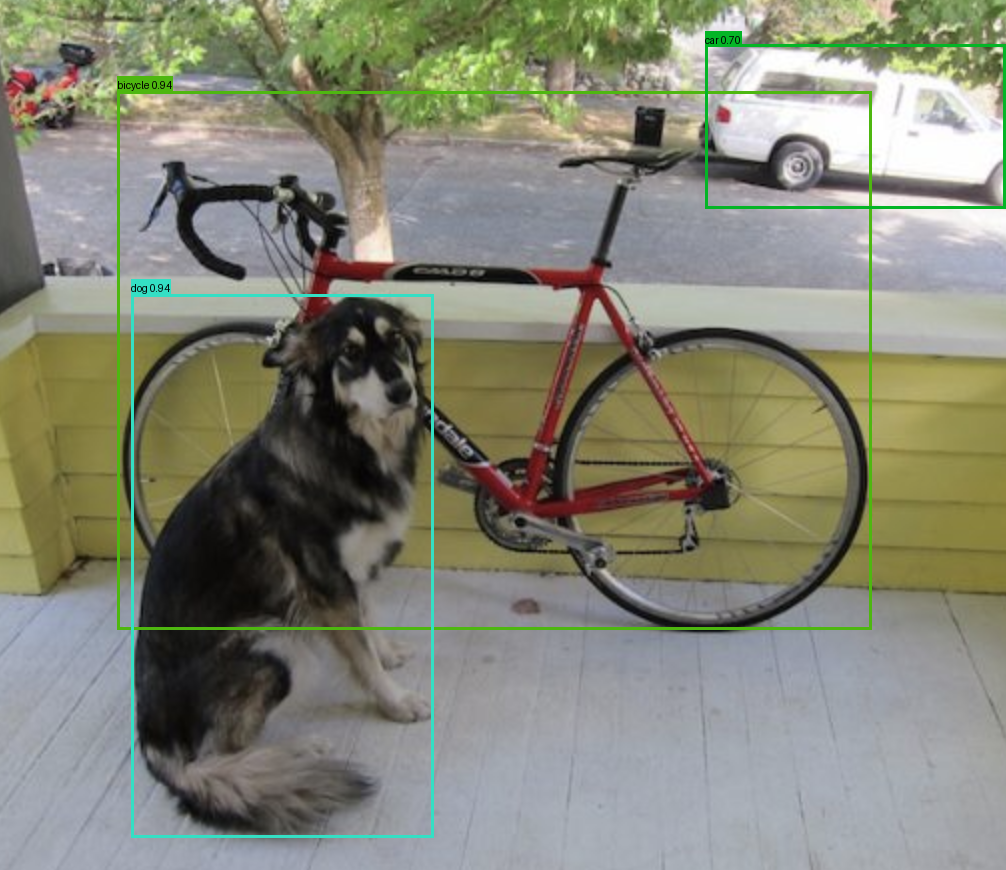

In [12]:
plot_bboxes_pil(img, pred, font_scale=2, thickness=3)